# ✈️ Projeto Spaceflights – Previsão de Esperas em Voos Comerciais

**Autor:** Lucas Coelho  
**Desafio:** Data Science Challenge @ EEF 2024 – ITA  
**Instituição organizadora:** Instituto Tecnológico de Aeronáutica (ITA)

---

## 🎯 Objetivo do Projeto

Este projeto tem como missão desenvolver um modelo preditivo robusto para **identificar a ocorrência de esperas (delays operacionais)** em voos comerciais nos 12 principais aeródromos do Brasil.

A previsão de esperas é uma tarefa **binária (espera = 0 ou 1)** e será avaliada por meio da métrica **F1-Score**, dada a importância de capturar corretamente os casos positivos (esperas).

---

## 📦 Fontes de Dados Utilizadas

Para construir esse modelo, serão utilizadas múltiplas fontes complementares de dados:

- **METAR** – Relatórios meteorológicos observacionais dos aeródromos.
- **METAF** – Previsões meteorológicas locais para terminais aeroportuários.
- **Imagens de Satélite** – Observações meteorológicas visuais por satélite.
- **Histórico de Troca de Cabeceira** – Mudanças de orientação de pista em uso, que impactam a operação.
- **Previsão de Troca de Cabeceira** – Sinalização futura de mudanças nas cabeceiras.

---

## 🧠 Missão Técnica

Construiremos um pipeline de machine learning que seguirá as etapas:

1. **Coleta e exploração dos dados brutos** (`01_raw`).
2. **Limpeza, transformação e engenharia de features** (`02_intermediate` a `04_feature`).
3. **Treinamento de modelos com validação rigorosa** (`06_models`).
4. **Geração de predições e submissão do resultado final** (`07_model_output`).

---

## 🔍 O que vamos buscar

- Compreender os principais fatores meteorológicos e operacionais que afetam a pontualidade dos voos.
- Utilizar técnicas de análise exploratória e pré-processamento para lidar com dados complexos (ex: METAR codificado).
- Desenvolver um modelo preditivo com foco em **alta generalização e interpretabilidade**, maximizando o F1.
- Implementar a solução inicial via **notebook exploratório**, com posterior migração para o framework **Kedro**.

---

> 🚀 *Vamos explorar, modelar e prever com rigor científico, código limpo e documentação clara. Boa decolagem!*


In [64]:
# ===============================
# 📦 Bibliotecas principais
# ===============================

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

# Modelagem e machine learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Engenharia de features
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Data & time
import datetime as dt
import time
from dateutil import parser

# Sistema e logging
import os
import logging
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Utilitários gerais
import json
import joblib
import gc
from metar.Metar import Metar



In [65]:
RAW_DIR = Path(r"C:\Users\DoIt\Downloads\data-science-challenge-at-eef-2024\spaceflights\data\01_raw")

# Caminhos completos dos arquivos
public_path = RAW_DIR / "public.csv"
sample_path = RAW_DIR / "sample.csv"
features_path = RAW_DIR / "features_pca_95.parquet"

# Leitura dos datasets
try:
    df_public = pd.read_csv(public_path)
    df_sample = pd.read_csv(sample_path)
    print("✅ Dados carregados com sucesso.")
except Exception as e:
    print("❌ Erro ao carregar os dados:", e)

# Visualização básica
print("\n📄 Dimensões do dataset público:", df_public.shape)
display(df_public.head())

print("\n📄 Dimensões do sample de submissão:", df_sample.shape)
display(df_sample.head())

✅ Dados carregados com sucesso.

📄 Dimensões do dataset público: (302399, 10)


,flightid,hora_ref,origem,destino,url_img_satelite,metaf,metar,prev_troca_cabeceira,troca_cabeceira_hora_anterior,espera
0,504a62621cd231d6ab67e674ce538cd3,2022-06-01T01:00:00Z,SBCF,SBFL,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBFL 010000Z 17009KT 140V200 9999 BKN030...,0,1,0.0
1,b0fd0f83644625ecc21f5261e8e5e347,2022-06-01T01:00:00Z,SBPA,SBFL,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBFL 010000Z 17009KT 140V200 9999 BKN030...,0,1,0.0
2,1210f0ca07ddca00d09a3e02d3b100d8,2022-06-01T01:00:00Z,SBSP,SBCF,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBCF 010000Z 12006KT CAVOK 21/14 Q1018=,0,0,0.0
3,b25032f34507cce285ee779446496568,2022-06-01T01:00:00Z,SBGR,SBCT,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBCT 010000Z 10006KT 7000 -RA BKN004 OVC...,0,0,0.0
4,00762a9892ecba7c66d1d87800d38cac,2022-06-01T01:00:00Z,SBSP,SBSV,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBSV 010000Z 11008KT 9999 FEW023 27/21 Q...,0,1,0.0



📄 Dimensões do sample de submissão: (90720, 2)


,flightid,espera
0,45e7978b9d88f934cc06c11b6f0edba7,1
1,16ed22b3755aa9196d16fdd2a173c98f,1
2,b548d2c700496e2536d78caf626aee17,1
3,e4cc2545104bcfe978912d39f0960f4e,1
4,ace87fdae884359186e9851c38b146fb,1


## 🔍 Análise Exploratória de Dados (EDA)

Vamos refinar a análise exploratória utilizando visualizações mais informativas e diretas, dividindo a análise em:

- 📌 **Distribuição de variáveis numéricas** com histogramas + KDE.
- 🧱 **Distribuição de variáveis categóricas** com contagem absoluta.
- 🔥 **Matriz de correlação** com destaque para a variável `espera`.

Essa abordagem permite obter insights visuais mais claros e identificar relações úteis para engenharia de features e seleção de variáveis para modelagem.


In [66]:
# Tipos de dados
print("📋 Tipos de dados:")
display(df_public.dtypes)

# Nulos por coluna
print("\n🔍 Valores nulos por coluna:")
display(df_public.isnull().sum().sort_values(ascending=False))

# Separar colunas numéricas e categóricas
num_cols = df_public.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_public.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\n✅ Variáveis numéricas: {num_cols}")
print(f"✅ Variáveis categóricas: {cat_cols}")


📋 Tipos de dados:


flightid                          object
hora_ref                          object
origem                            object
destino                           object
url_img_satelite                  object
metaf                             object
metar                             object
prev_troca_cabeceira               int64
troca_cabeceira_hora_anterior      int64
espera                           float64
dtype: object


🔍 Valores nulos por coluna:


metaf                            146662
espera                            90720
url_img_satelite                   3733
metar                              1629
flightid                              0
hora_ref                              0
origem                                0
destino                               0
prev_troca_cabeceira                  0
troca_cabeceira_hora_anterior         0
dtype: int64


✅ Variáveis numéricas: ['prev_troca_cabeceira', 'troca_cabeceira_hora_anterior', 'espera']
✅ Variáveis categóricas: ['flightid', 'hora_ref', 'origem', 'destino', 'url_img_satelite', 'metaf', 'metar']


In [67]:
# Histograma com KDE para colunas numéricas
def plot_numerics(df, cols):
    for col in cols:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], kde=True, bins=30, color='dodgerblue')
        plt.title(f'Distribuição de {col}', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Frequência')
        plt.grid(True)
        plt.show()


In [68]:
def plot_categoricals(df, cols, target='espera'):
    for col in cols:
        plt.figure(figsize=(8, 4))
        sns.countplot(data=df, x=col, hue=target, palette='Set2')
        plt.title(f'Distribuição de {col} por {target}')
        plt.xticks(rotation=45)
        plt.grid(True, axis='y')
        plt.show()

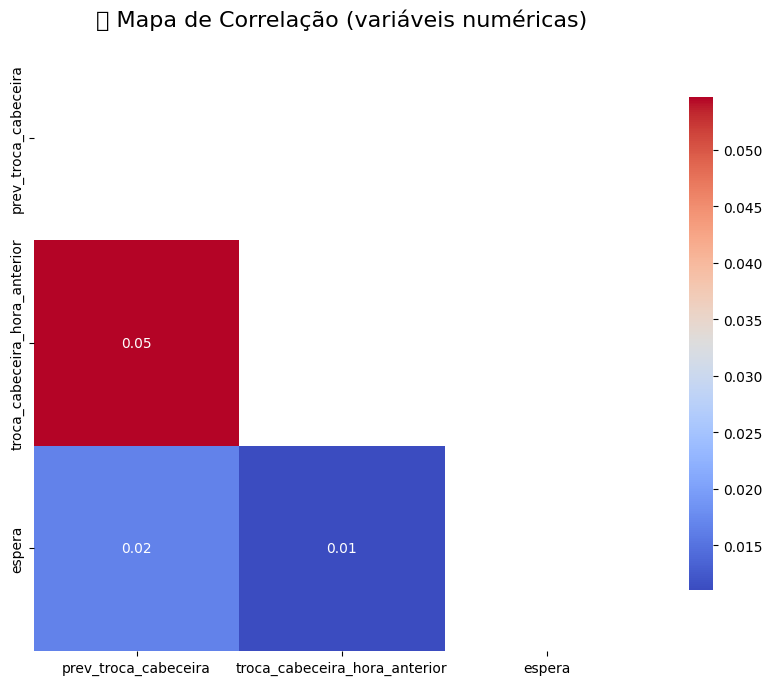

🔗 Correlação com 'espera':


prev_troca_cabeceira             0.016673
troca_cabeceira_hora_anterior    0.011102
Name: espera, dtype: float64

In [69]:
# Correlação numérica
plt.figure(figsize=(10, 8))
corr = df_public[num_cols].corr()

# Destaque para 'espera'
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True,
            mask=np.triu(corr), cbar_kws={"shrink": .8})
plt.title("📈 Mapa de Correlação (variáveis numéricas)", fontsize=16)
plt.show()

# Correlação direta com 'espera'
espera_corr = corr['espera'].drop('espera').sort_values(key=abs, ascending=False)
print("🔗 Correlação com 'espera':")
display(espera_corr)


## 🧹 Etapa de Tratamento e Engenharia de Features

Nesta etapa, iremos tratar o conjunto de dados e realizar a criação de novas variáveis (features) que possam enriquecer a capacidade preditiva do modelo.

### 📌 Etapas previstas:

#### 1. **Filtragem e limpeza inicial**
- Separar os dados com e sem a variável alvo `espera`.
- Remover colunas irrelevantes ou não tratáveis no escopo atual:
  - `url_img_satelite`: sem uso direto sem modelo de visão computacional.
  - `metaf` e `metar`: só serão mantidos se processados via parsing.

#### 2. **Criação de colunas a partir de `hora_ref`**
- Extrair informações temporais úteis como:
  - Hora (`hora`)
  - Dia do mês (`dia`)
  - Dia da semana (`dia_semana`)
  - Parte do dia (manhã/tarde/noite/madrugada)
- Essas variáveis ajudam a capturar padrões operacionais e meteorológicos recorrentes.

#### 3. **Parsing meteorológico (`metar`, `metaf`)**
- Aplicar biblioteca `python-metar` para extrair variáveis numéricas como:
  - Velocidade e direção do vento
  - Pressão atmosférica
  - Temperatura e ponto de orvalho
  - Nível de nebulosidade
- Esses fatores são relevantes para operações de pouso/decolagem e podem influenciar a ocorrência de esperas.

#### 4. **Criação de defasagens (lags)**
- Gerar **lags temporais** de 1, 2 e 3 horas para colunas críticas, por aeroporto:
  - `prev_troca_cabeceira`
  - `troca_cabeceira_hora_anterior`
- O objetivo é capturar **tendências operacionais ou sequências** que antecedem esperas.

#### 5. **Codificação de variáveis categóricas**
- Aplicar codificação adequada:
  - `LabelEncoder` ou `One-Hot` para `origem`, `destino`, etc.

#### 6. **Tratamento de valores nulos**
- Decidir como tratar colunas parciais (ex: preencher com medianas, categorizar como "desconhecido", etc).

---

> Ao final dessa etapa, teremos um dataset limpo, enriquecido com novas variáveis e pronto para treinamento do modelo preditivo.


In [70]:
def extrair_temporais(df, col='hora_ref'):
    """
    Extrai múltiplas features de data e hora a partir da coluna 'hora_ref'.

    Parâmetros:
    -----------
    df : pd.DataFrame
        DataFrame contendo a coluna de data/hora.
    col : str
        Nome da coluna que contém os timestamps.

    Retorna:
    --------
    df : pd.DataFrame
        DataFrame original com novas colunas temporais adicionadas.
    """
    # Conversão segura para datetime
    df[col] = pd.to_datetime(df[col], errors='coerce')

    # Extrações básicas
    df['hora'] = df[col].dt.hour
    df['dia'] = df[col].dt.day
    df['mes'] = df[col].dt.month
    df['dia_semana'] = df[col].dt.weekday  # 0 = segunda, 6 = domingo
    df['fim_de_semana'] = df['dia_semana'].isin([5, 6]).astype(int)

    # Faixas de horário (categorias)
    def faixa_horaria(hora):
        if 0 <= hora < 6:
            return 'madrugada'
        elif 6 <= hora < 12:
            return 'manha'
        elif 12 <= hora < 18:
            return 'tarde'
        else:
            return 'noite'
    
    df['periodo_dia'] = df['hora'].apply(faixa_horaria)

    return df

In [71]:
df_public = extrair_temporais(df_public)

df_public[['hora_ref', 'hora', 'dia_semana', 'periodo_dia']].head()

,hora_ref,hora,dia_semana,periodo_dia
0,2022-06-01 01:00:00+00:00,1,2,madrugada
1,2022-06-01 01:00:00+00:00,1,2,madrugada
2,2022-06-01 01:00:00+00:00,1,2,madrugada
3,2022-06-01 01:00:00+00:00,1,2,madrugada
4,2022-06-01 01:00:00+00:00,1,2,madrugada


In [72]:
def parsear_relatorios(df, coluna='metar', prefixo='metar_'):
    """
    Faz o parsing das strings METAR ou METAF e extrai features meteorológicas.

    Parâmetros:
    -----------
    df : pd.DataFrame
        DataFrame contendo os relatórios METAR/METAF.
    coluna : str
        Nome da coluna com os relatórios (ex: 'metar' ou 'metaf').
    prefixo : str
        Prefixo para nomear as colunas resultantes.

    Retorna:
    --------
    pd.DataFrame com as novas colunas adicionadas.
    """
    # Listas para armazenar valores extraídos
    temperatura = []
    ponto_orvalho = []
    pressao = []
    vento_vel = []
    vento_dir = []
    visibilidade = []

    for texto in tqdm(df[coluna], desc=f"Parsing {coluna}"):
        try:
            if pd.isna(texto):
                raise ValueError("Texto vazio")
            metar_obj = Metar(texto)

            temperatura.append(metar_obj.temp.value() if metar_obj.temp else np.nan)
            ponto_orvalho.append(metar_obj.dewpt.value() if metar_obj.dewpt else np.nan)
            pressao.append(metar_obj.press.value() if metar_obj.press else np.nan)
            vento_vel.append(metar_obj.wind_speed.value() if metar_obj.wind_speed else np.nan)
            vento_dir.append(metar_obj.wind_dir.value() if metar_obj.wind_dir else np.nan)
            visibilidade.append(metar_obj.vis.value() if metar_obj.vis else np.nan)

        except Exception:
            temperatura.append(np.nan)
            ponto_orvalho.append(np.nan)
            pressao.append(np.nan)
            vento_vel.append(np.nan)
            vento_dir.append(np.nan)
            visibilidade.append(np.nan)

    # Adiciona as colunas ao DataFrame
    df[f'{prefixo}temp'] = temperatura
    df[f'{prefixo}dewpoint'] = ponto_orvalho
    df[f'{prefixo}pressure'] = pressao
    df[f'{prefixo}wind_speed'] = vento_vel
    df[f'{prefixo}wind_dir'] = vento_dir
    df[f'{prefixo}visibility'] = visibilidade

    return df

In [73]:
from tqdm.notebook import tqdm

df_public = parsear_relatorios(df_public, coluna='metar', prefixo='metar')

df_public.head()

Parsing metar:   0%|          | 0/302399 [00:00<?, ?it/s]

,flightid,hora_ref,origem,destino,url_img_satelite,metaf,metar,prev_troca_cabeceira,troca_cabeceira_hora_anterior,espera,...,mes,dia_semana,fim_de_semana,periodo_dia,metartemp,metardewpoint,metarpressure,metarwind_speed,metarwind_dir,metarvisibility
0,504a62621cd231d6ab67e674ce538cd3,2022-06-01 01:00:00+00:00,SBCF,SBFL,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBFL 010000Z 17009KT 140V200 9999 BKN030...,0,1,0.0,...,6,2,0,madrugada,NaN,NaN,NaN,NaN,NaN,NaN
1,b0fd0f83644625ecc21f5261e8e5e347,2022-06-01 01:00:00+00:00,SBPA,SBFL,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBFL 010000Z 17009KT 140V200 9999 BKN030...,0,1,0.0,...,6,2,0,madrugada,NaN,NaN,NaN,NaN,NaN,NaN
2,1210f0ca07ddca00d09a3e02d3b100d8,2022-06-01 01:00:00+00:00,SBSP,SBCF,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBCF 010000Z 12006KT CAVOK 21/14 Q1018=,0,0,0.0,...,6,2,0,madrugada,NaN,NaN,NaN,NaN,NaN,NaN
3,b25032f34507cce285ee779446496568,2022-06-01 01:00:00+00:00,SBGR,SBCT,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBCT 010000Z 10006KT 7000 -RA BKN004 OVC...,0,0,0.0,...,6,2,0,madrugada,NaN,NaN,NaN,NaN,NaN,NaN
4,00762a9892ecba7c66d1d87800d38cac,2022-06-01 01:00:00+00:00,SBSP,SBSV,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBSV 010000Z 11008KT 9999 FEW023 27/21 Q...,0,1,0.0,...,6,2,0,madrugada,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
# Ver alguns valores únicos
df_public['metar'].dropna().unique()[:5]


array(['METAR SBFL 010000Z 17009KT 140V200 9999 BKN030 14/07 Q1020=',
       'METAR SBCF 010000Z 12006KT CAVOK 21/14 Q1018=',
       'METAR SBCT 010000Z 10006KT 7000 -RA BKN004 OVC012 10/10 Q1019=',
       'METAR SBSV 010000Z 11008KT 9999 FEW023 27/21 Q1014=',
       'METAR SBPA 010000Z VRB03KT CAVOK 09/04 Q1021='], dtype=object)

In [75]:
def testar_parsing_amostral(df, coluna='metar', n=10):
    from metar.Metar import Metar

    print(f"🎯 Testando os primeiros {n} relatórios da coluna: {coluna}\n")
    
    for i, texto in enumerate(df[coluna].dropna().unique()[:n]):
        print(f"🔹 Exemplo {i+1}:")
        print("Texto:", texto)
        try:
            m = Metar(texto)
            print("✅ Parsing OK")
            print("→ Temp:", m.temp.value() if m.temp else "n/a")
            print("→ Wind:", m.wind_speed.value() if m.wind_speed else "n/a")
            print("→ Pressure:", m.press.value() if m.press else "n/a")
        except Exception as e:
            print("❌ Erro no parsing:", e)
        print("---")


In [76]:
testar_parsing_amostral(df_public)


🎯 Testando os primeiros 10 relatórios da coluna: metar

🔹 Exemplo 1:
Texto: METAR SBFL 010000Z 17009KT 140V200 9999 BKN030 14/07 Q1020=
❌ Erro no parsing: Unparsed groups in body: Q1020=
---
🔹 Exemplo 2:
Texto: METAR SBCF 010000Z 12006KT CAVOK 21/14 Q1018=
❌ Erro no parsing: Unparsed groups in body: Q1018=
---
🔹 Exemplo 3:
Texto: METAR SBCT 010000Z 10006KT 7000 -RA BKN004 OVC012 10/10 Q1019=
❌ Erro no parsing: Unparsed groups in body: Q1019=
---
🔹 Exemplo 4:
Texto: METAR SBSV 010000Z 11008KT 9999 FEW023 27/21 Q1014=
❌ Erro no parsing: Unparsed groups in body: Q1014=
---
🔹 Exemplo 5:
Texto: METAR SBPA 010000Z VRB03KT CAVOK 09/04 Q1021=
❌ Erro no parsing: Unparsed groups in body: Q1021=
---
🔹 Exemplo 6:
Texto: METAR SBBR 010000Z 07002KT CAVOK 21/08 Q1018=
❌ Erro no parsing: Unparsed groups in body: Q1018=
---
🔹 Exemplo 7:
Texto: METAR SBGR 010000Z 13005KT 9999 OVC009 16/15 Q1019=
❌ Erro no parsing: Unparsed groups in body: Q1019=
---
🔹 Exemplo 8:
Texto: METAR SBGL 010000Z 10002KT 9999 SC

In [77]:
import re

def parsear_metar_regex(df, coluna='metar', prefixo='metar_'):
    temp_celsius = []
    pressao = []
    visibilidade = []
    vento_speed = []
    vento_dir = []

    padrao_temp = re.compile(r'(\d{2})/(\d{2})')
    padrao_pressao = re.compile(r'Q(\d{4})')
    padrao_visibilidade = re.compile(r'\s(\d{4})\s')
    padrao_vento = re.compile(r'(\d{3})(\d{2})KT')

    for texto in df[coluna].fillna("").astype(str):
        try:
            # Temperatura
            temp_match = padrao_temp.search(texto)
            temp = int(temp_match.group(1)) if temp_match else None
        except:
            temp = None

        try:
            dew = int(temp_match.group(2)) if temp_match else None
        except:
            dew = None

        try:
            press_match = padrao_pressao.search(texto)
            pres = int(press_match.group(1)) if press_match else None
        except:
            pres = None

        try:
            vis_match = padrao_visibilidade.search(texto)
            vis = int(vis_match.group(1)) if vis_match else None
        except:
            vis = None

        try:
            vento_match = padrao_vento.search(texto)
            v_dir = int(vento_match.group(1)) if vento_match else None
            v_spd = int(vento_match.group(2)) if vento_match else None
        except:
            v_dir, v_spd = None, None

        temp_celsius.append(temp)
        pressao.append(pres)
        visibilidade.append(vis)
        vento_speed.append(v_spd)
        vento_dir.append(v_dir)

    df[f'{prefixo}temp'] = temp_celsius
    df[f'{prefixo}dewpoint'] = dew
    df[f'{prefixo}pressure'] = pressao
    df[f'{prefixo}visibility'] = visibilidade
    df[f'{prefixo}wind_speed'] = vento_speed
    df[f'{prefixo}wind_dir'] = vento_dir

    return df


In [78]:
df_public = parsear_metar_regex(df_public, coluna='metar', prefixo='metar_')


In [79]:
df_public.isnull().sum()

flightid                              0
hora_ref                              0
origem                                0
destino                               0
url_img_satelite                   3733
metaf                            146662
metar                              1629
prev_troca_cabeceira                  0
troca_cabeceira_hora_anterior         0
espera                            90720
hora                                  0
dia                                   0
mes                                   0
dia_semana                            0
fim_de_semana                         0
periodo_dia                           0
metartemp                        302399
metardewpoint                    302399
metarpressure                    302399
metarwind_speed                  302399
metarwind_dir                    302399
metarvisibility                  302399
metar_temp                         2138
metar_dewpoint                        0
metar_pressure                     1630


In [80]:
colunas_nulas = [
    'metartemp', 'metardewpoint', 'metarpressure',
    'metarwind_speed', 'metarwind_dir', 'metarvisibility'
]

df_public.drop(columns=colunas_nulas, inplace=True, errors='ignore')


In [81]:
df_public.head()

,flightid,hora_ref,origem,destino,url_img_satelite,metaf,metar,prev_troca_cabeceira,troca_cabeceira_hora_anterior,espera,...,mes,dia_semana,fim_de_semana,periodo_dia,metar_temp,metar_dewpoint,metar_pressure,metar_visibility,metar_wind_speed,metar_wind_dir
0,504a62621cd231d6ab67e674ce538cd3,2022-06-01 01:00:00+00:00,SBCF,SBFL,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBFL 010000Z 17009KT 140V200 9999 BKN030...,0,1,0.0,...,6,2,0,madrugada,14.0,19,1020.0,9999.0,9.0,170.0
1,b0fd0f83644625ecc21f5261e8e5e347,2022-06-01 01:00:00+00:00,SBPA,SBFL,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBFL 010000Z 17009KT 140V200 9999 BKN030...,0,1,0.0,...,6,2,0,madrugada,14.0,19,1020.0,9999.0,9.0,170.0
2,1210f0ca07ddca00d09a3e02d3b100d8,2022-06-01 01:00:00+00:00,SBSP,SBCF,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBCF 010000Z 12006KT CAVOK 21/14 Q1018=,0,0,0.0,...,6,2,0,madrugada,21.0,19,1018.0,NaN,6.0,120.0
3,b25032f34507cce285ee779446496568,2022-06-01 01:00:00+00:00,SBGR,SBCT,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBCT 010000Z 10006KT 7000 -RA BKN004 OVC...,0,0,0.0,...,6,2,0,madrugada,10.0,19,1019.0,7000.0,6.0,100.0
4,00762a9892ecba7c66d1d87800d38cac,2022-06-01 01:00:00+00:00,SBSP,SBSV,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBSV 010000Z 11008KT 9999 FEW023 27/21 Q...,0,1,0.0,...,6,2,0,madrugada,27.0,19,1014.0,9999.0,8.0,110.0


In [82]:
def gerar_lags(df, colunas_lag, grupo='origem', tempo='hora_ref', lags=[1, 2, 3]):
    """
    Cria variáveis defasadas (lags) para colunas específicas com base em grupos e tempo.

    Parâmetros:
    -----------
    df : pd.DataFrame
        DataFrame de entrada.
    colunas_lag : list
        Lista de colunas numéricas para aplicar lags.
    grupo : str
        Coluna usada para agrupar (ex: aeroporto).
    tempo : str
        Coluna de tempo usada para ordenar (deve estar no formato datetime).
    lags : list
        Lista de defasagens (em horas).

    Retorna:
    --------
    df : pd.DataFrame com novas colunas de lag adicionadas.
    """
    df = df.sort_values(by=[grupo, tempo])
    
    for col in colunas_lag:
        for lag in lags:
            nova_col = f'{col}_lag_{lag}h'
            df[nova_col] = df.groupby(grupo)[col].shift(lag)

    return df


In [83]:
# Garante que hora_ref esteja em datetime (caso ainda não esteja)
df_public['hora_ref'] = pd.to_datetime(df_public['hora_ref'])

# Colunas que queremos aplicar os lags
colunas_para_lag = ['prev_troca_cabeceira', 'troca_cabeceira_hora_anterior']

# Aplicar os lags
df_public = gerar_lags(df_public, colunas_lag=colunas_para_lag)


In [84]:
df_public[[col for col in df_public.columns if 'lag_' in col]].sample(10)


,prev_troca_cabeceira_lag_1h,prev_troca_cabeceira_lag_2h,prev_troca_cabeceira_lag_3h,troca_cabeceira_hora_anterior_lag_1h,troca_cabeceira_hora_anterior_lag_2h,troca_cabeceira_hora_anterior_lag_3h
37360,0.0,0.0,0.0,1.0,1.0,1.0
195180,0.0,0.0,0.0,1.0,0.0,0.0
56380,0.0,0.0,0.0,0.0,0.0,1.0
222021,1.0,1.0,1.0,0.0,0.0,0.0
156599,1.0,1.0,1.0,0.0,0.0,0.0
301594,0.0,0.0,0.0,0.0,0.0,0.0
9935,0.0,0.0,0.0,0.0,0.0,0.0
59443,1.0,1.0,1.0,0.0,0.0,0.0
43019,0.0,0.0,0.0,0.0,0.0,0.0
28182,0.0,1.0,1.0,0.0,0.0,0.0


In [85]:
def testar_parsing_metaf(df, coluna='metaf', n=10):
    print(f"\n🔍 Testando os primeiros {n} METAFs da coluna: {coluna}\n")

    for i, texto in enumerate(df[coluna].dropna().unique()[:n]):
        print(f"\n📘 Exemplo {i+1}:")
        print("Texto:", texto)
        try:
            m = Metar(texto)
            print("✅ Parsing OK")
            print("🌡️ Temp:", m.temp.value() if m.temp else "n/a")
            print("💨 Wind:", m.wind_speed.value() if m.wind_speed else "n/a")
            print("📉 Pressure:", m.press.value() if m.press else "n/a")
        except Exception as e:
            print("❌ Erro no parsing:", e)
        print("—" * 40)


In [86]:
testar_parsing_metaf(df_public)



🔍 Testando os primeiros 10 METAFs da coluna: metaf


📘 Exemplo 1:
Texto: METAF SBGR 010300Z  11008KT 1000     BR OVC033   15/14 Q1017= 
❌ Erro no parsing: Unparsed groups in body: METAF Q1017=
————————————————————————————————————————

📘 Exemplo 2:
Texto: METAF SBKP 010800Z  11008KT 2000     BR BKN033   17/15 Q1015= 
❌ Erro no parsing: Unparsed groups in body: METAF Q1015=
————————————————————————————————————————

📘 Exemplo 3:
Texto: METAF SBSP 010900Z  14004KT 0600 FG     OVC033   16/16 Q1015= 
❌ Erro no parsing: Unparsed groups in body: METAF Q1015=
————————————————————————————————————————

📘 Exemplo 4:
Texto: METAF SBGR 010900Z  10005KT 1000     BR OVC033   16/15 Q1015= 
❌ Erro no parsing: Unparsed groups in body: METAF Q1015=
————————————————————————————————————————

📘 Exemplo 5:
Texto: METAF SBGR 011000Z  10006KT 1000     BR OVC033   16/15 Q1017= 
❌ Erro no parsing: Unparsed groups in body: METAF Q1017=
————————————————————————————————————————

📘 Exemplo 6:
Texto: METAF SBSP 01100

In [87]:
import re

def extrair_info_metaf(texto):
    try:
        wind_match = re.search(r'(\d{5})KT', texto)
        vis_match = re.search(r'\s(\d{4})\s', texto)
        temp_match = re.search(r'(\d{2})/(\d{2})', texto)
        press_match = re.search(r'Q(\d{4})', texto)

        return {
            'metaf_wind_speed': int(wind_match.group(1)[3:]) if wind_match else None,
            'metaf_wind_dir': int(wind_match.group(1)[:3]) if wind_match else None,
            'metaf_visibility': int(vis_match.group(1)) if vis_match else None,
            'metaf_temp': int(temp_match.group(1)) if temp_match else None,
            'metaf_dewpoint': int(temp_match.group(2)) if temp_match else None,
            'metaf_pressure': int(press_match.group(1)) if press_match else None
        }
    except:
        return {
            'metaf_wind_speed': None,
            'metaf_wind_dir': None,
            'metaf_visibility': None,
            'metaf_temp': None,
            'metaf_dewpoint': None,
            'metaf_pressure': None
        }


In [88]:
extrair_info_metaf(df_public['metaf'].iloc[0])

{'metaf_wind_speed': None,
 'metaf_wind_dir': None,
 'metaf_visibility': None,
 'metaf_temp': None,
 'metaf_dewpoint': None,
 'metaf_pressure': None}

In [89]:
metaf_info = df_public['metaf'].apply(extrair_info_metaf)
metaf_df = pd.DataFrame(metaf_info.tolist())
df_public = pd.concat([df_public, metaf_df], axis=1)


In [90]:
# 1. Carregar os dados do PCA
df_pca = pd.read_parquet(features_path)  # já deve conter 'flightid' como coluna

# 2. Verificar colunas disponíveis
print(df_pca.columns)

# 3. Fazer o merge pelo flightid, mantendo todas as linhas do df_public
df_merged = df_public.merge(df_pca, how='left', on='flightid')  # ou 'id' dependendo da sua coluna-chave

# 1. Recalcule as colunas PCA presentes no df_merged
pca_cols = [col for col in df_pca.columns if col != 'flightid' and col in df_merged.columns]

# 2. Preencha os nulos com a média apenas nas colunas que existem
for col in pca_cols:
    mean_val = df_merged[col].mean()
    df_merged[col].fillna(mean_val, inplace=True)

Index(['flightid', 'hora_ref', 'origem', 'destino', 'url_img_satelite',
       'metaf', 'metar', 'prev_troca_cabeceira',
       'troca_cabeceira_hora_anterior', 'espera',
       ...
       'pca_215', 'pca_216', 'pca_217', 'pca_218', 'pca_219', 'pca_220',
       'pca_221', 'pca_222', 'pca_223', 'pca_224'],
      dtype='object', length=235)


In [91]:
print("Colunas PCA disponíveis no df_pca:")
print(df_pca.columns.tolist())

print("Colunas PCA realmente presentes no df_merged:")
print(pca_cols)

# Garantir que flightid está presente e o merge foi feito
assert 'flightid' in df_merged.columns


Colunas PCA disponíveis no df_pca:
['flightid', 'hora_ref', 'origem', 'destino', 'url_img_satelite', 'metaf', 'metar', 'prev_troca_cabeceira', 'troca_cabeceira_hora_anterior', 'espera', 'pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5', 'pca_6', 'pca_7', 'pca_8', 'pca_9', 'pca_10', 'pca_11', 'pca_12', 'pca_13', 'pca_14', 'pca_15', 'pca_16', 'pca_17', 'pca_18', 'pca_19', 'pca_20', 'pca_21', 'pca_22', 'pca_23', 'pca_24', 'pca_25', 'pca_26', 'pca_27', 'pca_28', 'pca_29', 'pca_30', 'pca_31', 'pca_32', 'pca_33', 'pca_34', 'pca_35', 'pca_36', 'pca_37', 'pca_38', 'pca_39', 'pca_40', 'pca_41', 'pca_42', 'pca_43', 'pca_44', 'pca_45', 'pca_46', 'pca_47', 'pca_48', 'pca_49', 'pca_50', 'pca_51', 'pca_52', 'pca_53', 'pca_54', 'pca_55', 'pca_56', 'pca_57', 'pca_58', 'pca_59', 'pca_60', 'pca_61', 'pca_62', 'pca_63', 'pca_64', 'pca_65', 'pca_66', 'pca_67', 'pca_68', 'pca_69', 'pca_70', 'pca_71', 'pca_72', 'pca_73', 'pca_74', 'pca_75', 'pca_76', 'pca_77', 'pca_78', 'pca_79', 'pca_80', 'pca_81', 'pca

In [118]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import OrdinalEncoder
from imblearn.over_sampling import SMOTE

def pipeline_modelo_kaggle(df_merged, salvar_csv=True):
    df = df_merged.copy()

    # 1. Remover colunas inúteis ou que causam erro
    cols_a_remover = [col for col in df.columns if any(x in col for x in ['url_img', 'metar', 'metaf', 'hora_ref_y', 'destino_y', 'origem_y'])]
    df.drop(columns=cols_a_remover, errors='ignore', inplace=True)

    # 2. Extrair features temporais
    if 'hora_ref_x' in df.columns:
        df['hora_ref_x'] = pd.to_datetime(df['hora_ref_x'], errors='coerce')
        df['hora'] = df['hora_ref_x'].dt.hour
        df['dia_semana'] = df['hora_ref_x'].dt.weekday
        df['fim_de_semana'] = df['dia_semana'].isin([5, 6]).astype(int)

    # 3. Remover colunas datetime restantes
    datetime_cols = df.select_dtypes(include=['datetime64', 'datetime64[ns, UTC]']).columns.tolist()
    df.drop(columns=datetime_cols, errors='ignore', inplace=True)

    # 4. Tratar colunas categóricas
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    df[cat_cols] = df[cat_cols].fillna('desconhecido').astype(str)

    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    df[cat_cols] = encoder.fit_transform(df[cat_cols])

    # 5. Preencher nulos numéricos
    df.fillna(df.mean(numeric_only=True), inplace=True)

    # 6. Separar treino/teste
    df_train = df[df['espera_x'].notnull()].copy()
    df_test = df[df['espera_x'].isnull()].copy()

    X = df_train.drop(columns=['espera_x'], errors='ignore')
    y = df_train['espera_x'].astype(int)

    # 7. Split + SMOTE
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # 8. Modelos
    modelos = {
        'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
        'XGBoost': XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
        'LightGBM': LGBMClassifier(n_estimators=100, random_state=42),
        'CatBoost': CatBoostClassifier(verbose=0, random_state=42)
    }

    resultados = {}
    for nome, modelo in modelos.items():
        modelo.fit(X_train_res, y_train_res)
        y_pred = modelo.predict(X_val)
        f1 = f1_score(y_val, y_pred)
        acc = accuracy_score(y_val, y_pred)
        resultados[nome] = {'f1': f1, 'acc': acc, 'modelo': modelo}
        print(f"✅ {nome}: F1={f1:.4f}, Acc={acc:.4f}")

    melhor = max(resultados, key=lambda m: resultados[m]['f1'])
    melhor_modelo = resultados[melhor]['modelo']
    print(f"\n🏆 Melhor modelo: {melhor} com F1 = {resultados[melhor]['f1']:.4f}")

    # 9. Submissão
    X_test = df_test[X.columns]
    y_pred_final = melhor_modelo.predict(X_test)

    df_submissao = pd.DataFrame({
        'flightid': df_test['flightid'].astype(int),
        'espera': y_pred_final.astype(int)
    })

    if salvar_csv:
        df_submissao.to_csv('submissao_final.csv', index=False)
        print("📁 Arquivo salvo: 'submissao_final.csv'")

    return melhor_modelo, resultados, df_submissao, X



In [123]:
melhor_modelo, resultados, submissao, X = pipeline_modelo_kaggle(df_merged)



✅ RandomForest: F1=0.0106, Acc=0.9876
✅ XGBoost: F1=0.0524, Acc=0.9880
[LightGBM] [Info] Number of positive: 238970, number of negative: 238970
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.128887 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 60702
[LightGBM] [Info] Number of data points in the train set: 477940, number of used features: 245
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
✅ LightGBM: F1=0.0502, Acc=0.9881
✅ CatBoost: F1=0.0716, Acc=0.9880

🏆 Melhor modelo: CatBoost com F1 = 0.0716
📁 Arquivo salvo: 'submissao_final.csv'


No objects info loaded


In [125]:
def mostrar_importancia_features(modelo, X, top_n=20):
    """
    Plota as top_n features mais importantes de um modelo treinado.
    """
    if hasattr(modelo, 'feature_importances_'):
        importancias = modelo.feature_importances_
        
        if len(importancias) != X.shape[1]:
            print(f"⚠️ Número de importâncias ({len(importancias)}) não bate com número de colunas de X ({X.shape[1]}). Verifique se X é o mesmo usado no treino.")
            return None
        
        features = pd.Series(importancias, index=X.columns)
        top_features = features.sort_values(ascending=False).head(top_n)

        plt.figure(figsize=(10, 6))
        sns.barplot(x=top_features.values, y=top_features.index)
        plt.title(f"Top {top_n} Features mais importantes")
        plt.xlabel("Importância")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()
        return top_features.index.tolist()
    else:
        print("⚠️ Este modelo não possui atributo 'feature_importances_'.")
        return None


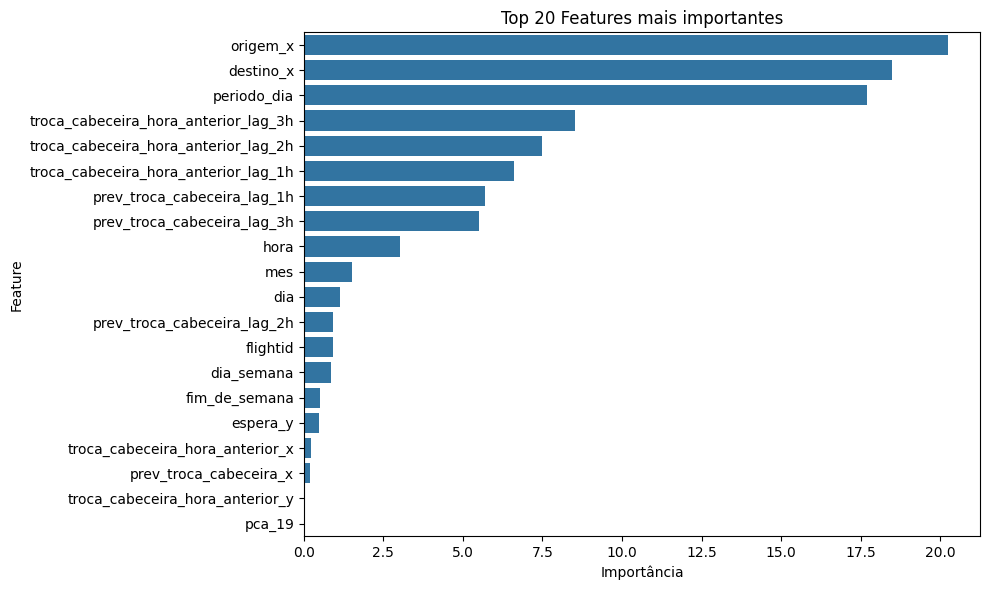

In [126]:

features_importantes = mostrar_importancia_features(melhor_modelo, X)


In [134]:
def testar_modelos_reduzidos(df_merged, features_usadas):
    df = df_merged.copy()

    # Manter somente as features + target
    colunas_utilizadas = features_usadas + ['espera_x']
    df = df[colunas_utilizadas]

    # Tratar categóricas
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    df[cat_cols] = df[cat_cols].fillna('desconhecido').astype(str)

    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    df[cat_cols] = encoder.fit_transform(df[cat_cols])

    # Preencher nulos numéricos
    df.fillna(df.mean(numeric_only=True), inplace=True)

    # Separar dados com target
    df_train = df[df['espera_x'].notnull()].copy()
    X = df_train.drop(columns=['espera_x'])
    y = df_train['espera_x'].astype(int)

    # Split
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Modelos
    modelos = {
        'XGBoost': XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
        'CatBoost': CatBoostClassifier(verbose=0, random_state=42)
    }

    resultados = {}
    for nome, modelo in modelos.items():
        modelo.fit(X_train_res, y_train_res)
        y_pred = modelo.predict(X_val)
        f1 = f1_score(y_val, y_pred)
        acc = accuracy_score(y_val, y_pred)
        resultados[nome] = {'f1': f1, 'acc': acc}
        print(f"✅ {nome}: F1={f1:.4f}, Acc={acc:.4f}")

    return resultados

In [135]:
resultados_reduzidos = testar_modelos_reduzidos(df_merged, features_importantes)


✅ XGBoost: F1=0.0501, Acc=0.9881
✅ CatBoost: F1=0.0813, Acc=0.9880


In [152]:
from sklearn.feature_selection import VarianceThreshold
import numpy as np

def preprocessar_dados_treinamento(df):
    df = df.copy()
    X = df.drop(columns=['espera_x'], errors='ignore')
    y = df['espera_x'].astype(int)

    # 1. Preencher nulos
    X = X.fillna(X.mean(numeric_only=True))
    X = X.fillna('desconhecido')

    # 2. Tratar categóricas com OrdinalEncoder
    cat_cols = X.select_dtypes(include='object').columns
    if len(cat_cols) > 0:
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X[cat_cols] = encoder.fit_transform(X[cat_cols].astype(str))

    # 3. Remover baixa variância (numéricas)
    selector = VarianceThreshold(threshold=0.001)
    selector.fit(X)
    colunas_filtradas = X.columns[selector.get_support()]
    X = X[colunas_filtradas]

    return X, y


In [153]:
def testar_modelos_com_tratamento(df_merged, features_usadas):
    df = df_merged.copy()

    # 1. Remover colunas inúteis ou com risco de vazamento
    cols_a_remover = [col for col in df.columns if any(x in col for x in ['url_img', 'metar', 'metaf', 'hora_ref_y', 'destino_y', 'origem_y'])]
    df.drop(columns=cols_a_remover, errors='ignore', inplace=True)

    # 2. Garantir datetime para criar colunas temporais
    if 'hora_ref_x' in df.columns:
        df['hora_ref_x'] = pd.to_datetime(df['hora_ref_x'], errors='coerce')
        df['hora'] = df['hora_ref_x'].dt.hour
        df['dia_semana'] = df['hora_ref_x'].dt.weekday
        df['fim_de_semana'] = df['dia_semana'].isin([5, 6]).astype(int)

    # 3. Remover colunas datetime restantes
    datetime_cols = df.select_dtypes(include=['datetime64', 'datetime64[ns, UTC]']).columns.tolist()
    df.drop(columns=datetime_cols, errors='ignore', inplace=True)

    # 4. Separar treino
    df_train = df[df['espera_x'].notnull()].copy()
    
    # 5. Selecionar apenas as features importantes + target
    colunas_modelo = features_usadas + ['espera_x']
    df_train = df_train[colunas_modelo]

    # 6. Aplicar tratamento completo
    X, y = preprocessar_dados_treinamento(df_train)

    # 7. Split
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    # 8. SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # 9. Modelos a testar
    modelos = {
        'XGBoost': XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
        'CatBoost': CatBoostClassifier(verbose=0, random_state=42)
    }

    resultados = {}
    for nome, modelo in modelos.items():
        modelo.fit(X_train_res, y_train_res)
        y_pred = modelo.predict(X_val)
        f1 = f1_score(y_val, y_pred)
        acc = accuracy_score(y_val, y_pred)
        resultados[nome] = {'f1': f1, 'acc': acc, 'modelo': modelo}
        print(f"✅ {nome}: F1={f1:.4f}, Acc={acc:.4f}")

    return resultados

In [154]:
resultados_final = testar_modelos_com_tratamento(df_merged, features_importantes)


✅ XGBoost: F1=0.0108, Acc=0.9826
✅ CatBoost: F1=0.0421, Acc=0.9828


In [172]:
def pipeline_final_kaggle(df, df_sample, top_n_features=30):
    import pandas as pd
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import f1_score, accuracy_score
    from sklearn.feature_selection import SelectKBest, f_classif
    from imblearn.over_sampling import SMOTE
    from xgboost import XGBClassifier
    from catboost import CatBoostClassifier

    target_col = 'espera' if 'espera' in df.columns else 'espera_x'

    # Treino
    df_train = df[df[target_col].notnull()].copy()
    df_test = df[df['flightid'].isin(df_sample['flightid'])].copy()

    X = df_train.drop(columns=[target_col, 'flightid'])
    y = df_train[target_col].astype(int)

    # Substituir NaNs
    X = X.fillna(0)

    # Seleção de features
    selector = SelectKBest(score_func=f_classif, k=top_n_features)
    X_selected = selector.fit_transform(X, y)
    features = X.columns[selector.get_support()]

    # Atualizar datasets
    X = df_train[features].fillna(0)
    X_test = df_test[features].fillna(0)

    # Split
    X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

    # SMOTE
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Modelos
    modelos = {
        'XGBoost': XGBClassifier(random_state=42, verbosity=0),
        'CatBoost': CatBoostClassifier(verbose=0, random_state=42)
    }

    resultados = {}
    melhor_f1 = 0
    melhor_modelo = None

    for nome, modelo in modelos.items():
        modelo.fit(X_train_res, y_train_res)
        y_pred = modelo.predict(X_val)
        f1 = f1_score(y_val, y_pred)
        acc = accuracy_score(y_val, y_pred)
        print(f"{nome}: F1={f1:.4f}, Acc={acc:.4f}")
        resultados[nome] = {'f1': f1, 'acc': acc, 'modelo': modelo}
        if f1 > melhor_f1:
            melhor_f1 = f1
            melhor_modelo = modelo

    print(f"🏆 Melhor modelo: {type(melhor_modelo).__name__} com F1 = {melhor_f1:.4f}")

    # Prever no df_test
    y_pred_final = melhor_modelo.predict(X_test)

    # Submissão
    df_sub = df_sample.copy()
    df_sub = df_sub[['flightid']]  # garantir ordem
    df_sub['espera'] = y_pred_final.astype(int)

    return melhor_modelo, resultados, df_sub


In [174]:
# Conferências obrigatórias:
assert len(df_sub) == len(df_sample)
assert df_sub['espera'].isin([0, 1]).all()
assert df_sub['flightid'].isin(df_sample['flightid']).all()
